# Import all required Libraries

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Exploratory Data Analysis & Data Preprocessing

In [6]:
df = pd.read_csv('/kaggle/input/datasets/shashwatwork/cerebral-stroke-predictionimbalaced-dataset/dataset.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,30669,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,30468,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,16523,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,56543,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,46136,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0


In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 43400 non-null  int64  
 1   gender             43400 non-null  object 
 2   age                43400 non-null  float64
 3   hypertension       43400 non-null  int64  
 4   heart_disease      43400 non-null  int64  
 5   ever_married       43400 non-null  object 
 6   work_type          43400 non-null  object 
 7   Residence_type     43400 non-null  object 
 8   avg_glucose_level  43400 non-null  float64
 9   bmi                41938 non-null  float64
 10  smoking_status     30108 non-null  object 
 11  stroke             43400 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 4.0+ MB


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,43400.000000,43400.000000,43400.000000,43400.000000,43400.000000,41938.000000,43400.000000
mean,36326.142350,42.217894,0.093571,0.047512,104.482750,28.605038,0.018041
std,21072.134879,22.519649,0.291235,0.212733,43.111751,7.770020,0.133103
min,1.000000,0.080000,0.000000,0.000000,55.000000,10.100000,0.000000
25%,18038.500000,24.000000,0.000000,0.000000,77.540000,23.200000,0.000000
50%,36351.500000,44.000000,0.000000,0.000000,91.580000,27.700000,0.000000
75%,54514.250000,60.000000,0.000000,0.000000,112.070000,32.900000,0.000000
max,72943.000000,82.000000,1.000000,1.000000,291.050000,97.600000,1.000000


In [8]:
df.isnull().sum()

id                       0
gender                   0
age                      0
hypertension             0
heart_disease            0
ever_married             0
work_type                0
Residence_type           0
avg_glucose_level        0
bmi                   1462
smoking_status       13292
stroke                   0
dtype: int64

# Class Imbalance

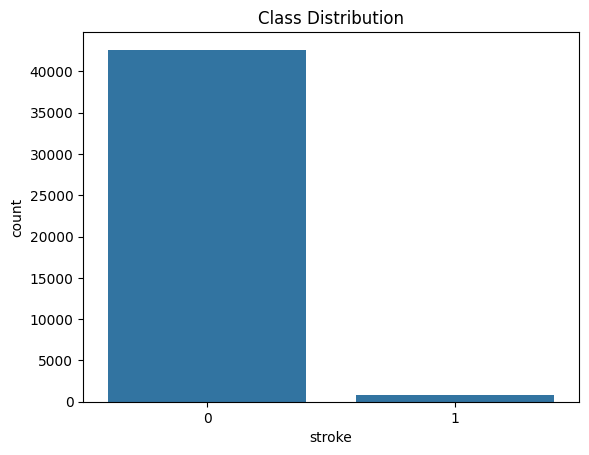

In [69]:
plt.figure()
sns.countplot(x='stroke', data=df)
plt.title("Class Distribution")
plt.savefig("class_distribution.png")
plt.show()

# Age VS Stroke

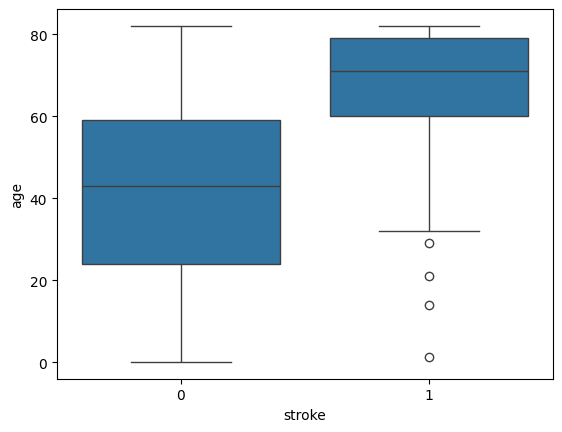

Stroke more common in older people


In [75]:
plt.figure()
sns.boxplot(x='stroke', y='age', data=df)
plt.savefig("age_vs_stroke.png")
plt.show()
print("Stroke more common in older people")


# Glucose VS Stroke

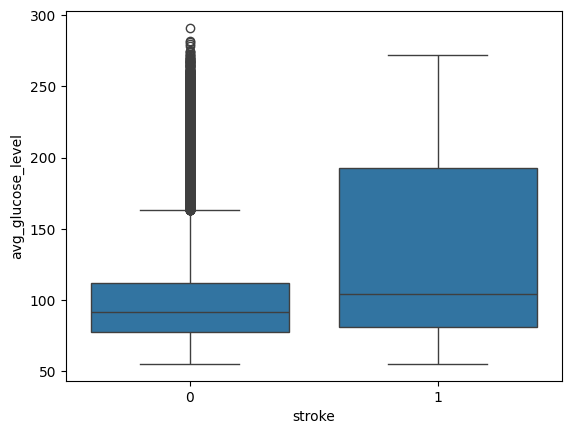

Higher glucose → higher stroke risk


In [76]:
plt.figure()
sns.boxplot(x='stroke', y='avg_glucose_level', data=df)
plt.savefig("glucose_vs_stroke.png")
plt.show()
print("Higher glucose → higher stroke risk")

# BMI Distribution

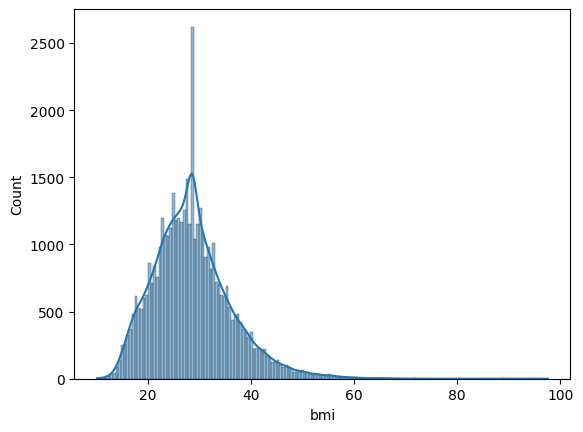

In [72]:
plt.figure()
sns.histplot(df['bmi'], kde=True)
plt.savefig("bmi_distribution.png")
plt.show()

# Hypertension VS Stroke

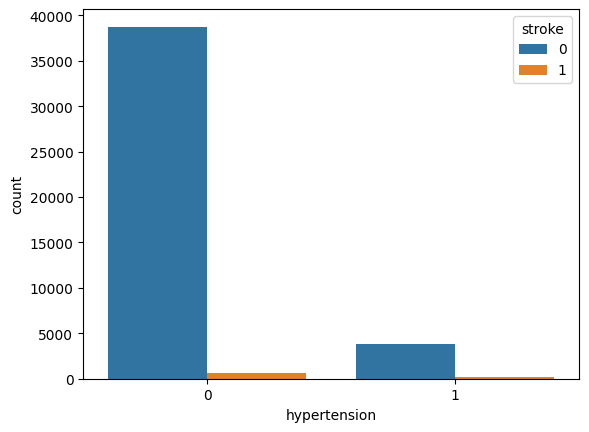

In [73]:
plt.figure()
sns.countplot(x='hypertension', hue='stroke', data=df)
plt.savefig("hypertension_vs_stroke.png")
plt.show()

df['bmi'].fillna(df['bmi'].mean(), inplace=True)

# Sample Model testing (Logistic Regression)

## Handle missing values

In [74]:
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())

## Defining X & Y

In [28]:
X = df.drop('stroke', axis=1)
y = df['stroke']

In [29]:
X = pd.get_dummies(X)

## Splitting Data into test and train set 

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Apply SMOTE (ONLY on training data)

In [32]:
from imblearn.over_sampling import SMOTE

In [35]:
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

## Train Model

In [37]:
from sklearn.linear_model import LogisticRegression

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_sm = scaler.fit_transform(X_train_sm)
X_test = scaler.transform(X_test)

In [40]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_sm, y_train_sm)

LogisticRegression(max_iter=1000)

## Predictions

In [43]:
y_pred = model.predict(X_test)
print(y_pred)

[0 0 0 ... 0 0 0]


## Evaluation Matrix

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      8519
           1       0.03      0.02      0.02       161

    accuracy                           0.97      8680
   macro avg       0.51      0.50      0.50      8680
weighted avg       0.96      0.97      0.97      8680

